In [241]:
import numpy as np
import pandas as pd
from datetime import datetime, time, date
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import holidays
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import joblib

In [191]:
data = pd.read_csv("denver_trips_synth.csv", low_memory=False)

In [192]:
data["SchLate"] = data["SchLate"].apply(
    lambda x: time(int(x // 3600), int((x % 3600) // 60), int(x % 60))
)
# extract hour from schtime
data["SchHour"] = data["SchLate"].apply(lambda x: x.hour)
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
print(data["Date"].max())
data["Month"] = data["Date"].dt.month
data["Day"] = data["Date"].dt.day
data["Year"] = data["Date"].dt.year
data["SchedStatusName"] = np.where(data["SchedStatusName"] == "Performed", 1, 0)
data = (
    data.pivot_table(
        index=["Month", "Day", "Year", "SchHour"],
        aggfunc={
            "ClientId": "nunique",
            "BookingId": "nunique",
            "ProviderName": "nunique",
            "PassCount": "sum",
            "Driver": "nunique",
            "Route": "nunique",
            "VehicleNumber": "nunique",
            "OTP": "mean",
            "SchedStatusName": "mean",
        },
    )
    .reset_index()
    .rename(
        columns={
            "ClientId": "clients",
            "BookingId": "trips",
            "ProviderName": "providers",
            "PassCount": "pass_count",
            "Driver": "drivers",
            "Route": "routes",
            "VehicleNumber": "vehicles",
            "SchedStatusName": "status",
            "OTP": "otp",
        }
    )
)

data["otp_pass"] = np.where(data["otp"] >= 0.9, 1, 0)

2027-04-18 00:00:00


1. Predict trip count based on date
2. Predict drivers, runs and vehicles based on previouly predicted variables

In [193]:
trips = data[["Month", "Day", "Year", "SchHour", "trips"]]

trips["season"] = trips["Month"].apply(lambda x: (x % 12 + 3) // 3)
trips["is_weekend"] = trips.apply(
    lambda x: 1 if datetime(x["Year"], x["Month"], x["Day"]).weekday() >= 5 else 0,
    axis=1,
)
us_holidays = holidays.US()
trips["is_holiday"] = trips.apply(
    lambda x: (
        1
        if datetime(int(x["Year"]), int(x["Month"]), int(x["Day"])).date()
        in us_holidays
        else 0
    ),
    axis=1,
)

In [194]:
trips

,Month,Day,Year,SchHour,trips,season,is_weekend,is_holiday
0,1,1,2025,6,120,1,0,1
1,1,1,2025,7,275,1,0,1
2,1,1,2025,8,252,1,0,1
3,1,1,2025,9,257,1,0,1
4,1,1,2025,10,222,1,0,1
...,...,...,...,...,...,...,...,...
12561,12,31,2026,16,178,1,0,0
12562,12,31,2026,17,86,1,0,0
12563,12,31,2026,18,69,1,0,0
12564,12,31,2026,19,86,1,0,0


In [195]:
for col in trips.columns:
    trips[col] = trips[col].astype(float)
X = trips.drop("trips", axis=1)
y = trips["trips"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [196]:
rfModel = RandomForestRegressor(
    n_estimators=505,
    random_state=42,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    verbose=1,
)

rfModel.fit(X_train, y_train)
y_pred = rfModel.predict(X_test)

# metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 152 tasks      | elapsed:    0.0s


Mean Squared Error: 258.49
R^2 Score: 0.94
Mean Absolute Error: 12.89


[Parallel(n_jobs=-1)]: Done 402 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 505 out of 505 | elapsed:    0.2s finished
[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 402 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 505 out of 505 | elapsed:    0.0s finished


In [244]:
pip install pyarrow

  Using cached pyarrow-23.0.1-cp312-cp312-win_amd64.whl.metadata (3.1 kB)
Using cached pyarrow-23.0.1-cp312-cp312-win_amd64.whl (27.6 MB)
Note: you may need to restart the kernel to use updated packages.


In [246]:
#save the rfmodel with joblib
joblib.dump(rfModel, "rf_model.pkl")

#save trips as parquet
import pyarrow
trips.to_parquet("trips.parquet", index=False)

ArrowKeyError: A type extension with name pandas.period already defined

In [197]:
future = pd.date_range(start="2026-04-19", end="2026-05-19", freq="h").to_frame(
    index=False, name="Date"
)

future[["Date", "SchHour"]] = future["Date"].apply(
    lambda x: pd.Series([x.date(), x.hour])
)

future["Date"] = pd.to_datetime(future["Date"], errors="coerce")
future["Month"] = future["Date"].dt.month
future["Day"] = future["Date"].dt.day
future["Year"] = future["Date"].dt.year

future = future.drop("Date", axis=1)

In [198]:
future["season"] = future["Month"].apply(lambda x: (x % 12 + 3) // 3)
future["is_weekend"] = future.apply(
    lambda x: 1 if datetime(x["Year"], x["Month"], x["Day"]).weekday() >= 5 else 0,
    axis=1,
)
us_holidays = holidays.US()
future["is_holiday"] = future.apply(
    lambda x: (
        1
        if datetime(int(x["Year"]), int(x["Month"]), int(x["Day"])).date()
        in us_holidays
        else 0
    ),
    axis=1,
)

future = future[['Month', 'Day', 'Year', 'SchHour', 'season', 'is_weekend', 'is_holiday']]

In [199]:
X_train.shape, future.shape

((10052, 7), (721, 7))

In [200]:
future['trips'] = rfModel.predict(future)


[Parallel(n_jobs=24)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=24)]: Done   2 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 152 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 402 tasks      | elapsed:    0.0s
[Parallel(n_jobs=24)]: Done 505 out of 505 | elapsed:    0.0s finished


In [201]:
future['trips'] = future['trips'].round().astype(int)

In [203]:
future['otp_pass'] = 1

In [204]:
future

,Month,Day,Year,SchHour,season,is_weekend,is_holiday,trips,otp_pass
0,4,19,2026,0,2,1,0,130,1
1,4,19,2026,1,2,1,0,130,1
2,4,19,2026,2,2,1,0,130,1
3,4,19,2026,3,2,1,0,130,1
4,4,19,2026,4,2,1,0,130,1
...,...,...,...,...,...,...,...,...,...
716,5,18,2026,20,2,0,0,20,1
717,5,18,2026,21,2,0,0,20,1
718,5,18,2026,22,2,0,0,20,1
719,5,18,2026,23,2,0,0,20,1


In [208]:
#we will predict drivers, vehicles, routes and status using deep learning tensorflow keras
present = data[["Month", "Day", "Year", "SchHour", "trips", "otp_pass", "drivers", "vehicles", "routes", "status"]]

In [210]:
X =  present[["Month", "Day", "Year", "SchHour", "trips", "otp_pass"]]
y = present[["drivers", "vehicles", "routes", "status"]]

X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.2, random_state=42)

In [224]:
#not linear
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(y_train.shape[1], activation="linear"),
])

c:\Users\moham\torch5080\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [225]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,124 (12.20 KB)

 Trainable params: 3,124 (12.20 KB)

 Non-trainable params: 0 (0.00 B)

In [226]:
early = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint(
    "best_model.h5", monitor="val_loss", save_best_only=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)

In [227]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

In [228]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=500,
    batch_size=32,
    callbacks=[early, checkpoint, reduce_lr],
)

Epoch 1/500
64/79 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step - loss: 13338.9159 - mae: 91.4056  
Epoch 1: val_loss improved from None to 3455.05615, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8211.9502 - mae: 71.7716 - val_loss: 3455.0562 - val_mae: 44.6153 - learning_rate: 0.0010
Epoch 2/500
73/79 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - loss: 4238.9700 - mae: 52.2130
Epoch 2: val_loss improved from 3455.05615 to 2031.31396, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3933.4709 - mae: 50.1533 - val_loss: 2031.3140 - val_mae: 35.0943 - learning_rate: 0.0010
Epoch 3/500
 1/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2808.6123 - mae: 41.3157
Epoch 3: val_loss improved from 2031.31396 to 1663.42712, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3030.8652 - mae: 43.2154 - val_loss: 1663.4271 - val_mae: 32.2235 - learning_rate: 0.0010
Epoch 4/500
 1/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2142.5796 - mae: 34.9065
Epoch 4: val_loss improved from 1663.42712 to 1443.90601, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2473.9233 - mae: 38.3348 - val_loss: 1443.9060 - val_mae: 30.0473 - learning_rate: 0.0010
Epoch 5/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 652us/step - loss: 2296.9117 - mae: 36.5827
Epoch 5: val_loss improved from 1443.90601 to 1071.89600, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2272.7134 - mae: 36.1763 - val_loss: 1071.8960 - val_mae: 25.8481 - learning_rate: 0.0010
Epoch 6/500
68/79 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - loss: 1931.7427 - mae: 32.9282
Epoch 6: val_loss did not improve from 1071.89600
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1917.9728 - mae: 32.7064 - val_loss: 1110.8077 - val_mae: 26.4289 - learning_rate: 0.0010
Epoch 7/500
74/79 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step - loss: 1893.2275 - mae: 32.2987
Epoch 7: val_loss improved from 1071.89600 to 1066.56787, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1804.5947 - mae: 31.3607 - val_loss: 1066.5679 - val_mae: 26.5514 - learning_rate: 0.0010
Epoch 8/500
 1/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1841.9534 - mae: 32.1371
Epoch 8: val_loss improved from 1066.56787 to 744.71680, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1643.1259 - mae: 29.5036 - val_loss: 744.7168 - val_mae: 22.5512 - learning_rate: 0.0010
Epoch 9/500
 1/79 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1219.0566 - mae: 26.2793
Epoch 9: val_loss did not improve from 744.71680
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1512.9293 - mae: 27.8994 - val_loss: 824.2986 - val_mae: 24.0238 - learning_rate: 0.0010
Epoch 10/500
 1/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1641.8181 - mae: 28.6237
Epoch 10: val_loss improved from 744.71680 to 352.21472, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1326.7295 - mae: 26.4062 - val_loss: 352.2147 - val_mae: 15.4944 - learning_rate: 0.0010
Epoch 11/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 644us/step - loss: 1227.3162 - mae: 25.3026
Epoch 11: val_loss improved from 352.21472 to 306.71082, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1200.4730 - mae: 24.8183 - val_loss: 306.7108 - val_mae: 14.5139 - learning_rate: 0.0010
Epoch 12/500
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step - loss: 1131.6372 - mae: 24.1064
Epoch 12: val_loss did not improve from 306.71082
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1157.1409 - mae: 24.3362 - val_loss: 521.3493 - val_mae: 19.2232 - learning_rate: 0.0010
Epoch 13/500
 1/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1239.0105 - mae: 23.5352
Epoch 13: val_loss did not improve from 306.71082
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1121.1338 - mae: 23.6193 - val_loss: 465.3723 - val_mae: 18.3596 - learning_rate: 0.0010
Epoch 14/500
 1/79 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1038.0773 - mae: 21.7393
Epoch 14: val_loss did not improve from 306.71082
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1048.8313 - mae: 22.6218 - val_loss: 431.5833 - val_mae: 17.4362 - learning_rate: 0.00

In [229]:
y_pred = model.predict(X_test)

315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 418us/step


In [230]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

Mean Squared Error: 306.71
R^2 Score: -70.46
Mean Absolute Error: 14.51


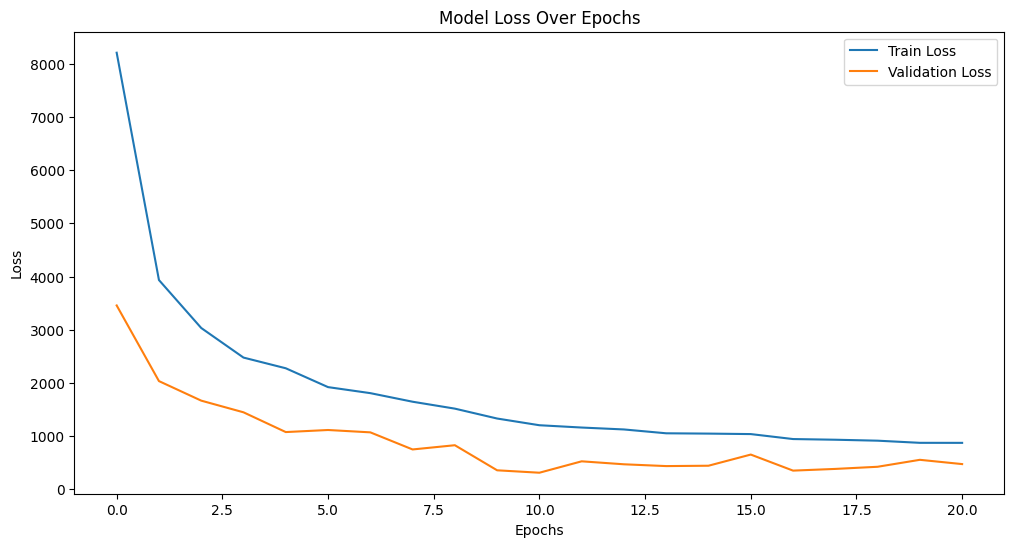

In [231]:
#plot the model
plt.figure(figsize=(12, 6))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [233]:
prediction = model.predict(future[["Month", "Day", "Year", "SchHour", "trips", "otp_pass"]])

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step


In [235]:
#assign then to future
future[["drivers", "vehicles", "routes", "status"]] = prediction

In [237]:
future.head(30)

,Month,Day,Year,SchHour,season,is_weekend,is_holiday,trips,otp_pass,drivers,vehicles,routes,status
0,4,19,2026,0,2,1,0,130,1,80.500626,78.044449,79.109047,1.917682
1,4,19,2026,1,2,1,0,130,1,80.342926,77.893776,78.956528,1.918774
2,4,19,2026,2,2,1,0,130,1,80.185234,77.743126,78.804016,1.919865
3,4,19,2026,3,2,1,0,130,1,80.027550,77.592468,78.651512,1.920957
4,4,19,2026,4,2,1,0,130,1,79.869865,77.441803,78.499008,1.922048
5,4,19,2026,5,2,1,0,130,1,79.712166,77.291138,78.346481,1.923142
6,4,19,2026,6,2,1,0,130,1,79.554482,77.140480,78.193977,1.924235
7,4,19,2026,7,2,1,0,218,1,114.854782,111.466034,113.091156,1.586783
8,4,19,2026,8,2,1,0,218,1,114.709007,111.325645,112.949425,1.587714
9,4,19,2026,9,2,1,0,218,1,114.563217,111.185242,112.807678,1.588646
